In [2]:
import pathlib
import scanpy as sc
import pandas as pd
import numpy as np

In [6]:
cancer_types = []
for file in pathlib.Path("data/").iterdir():
    #print(file)
    adata = sc.read_h5ad(file, backed="r")
    obs = adata.obs[~adata.obs["sample"].duplicated()]
    if obs["cancer_type"].isna().all():
        print(file)
    cancer_type = obs["cancer_type"].map(map_cancer_type)
    cancer_types.append(cancer_type)

In [3]:
def map_cancer_type(cancer_type):
    if cancer_type.lower() in tcga_mapping.keys():
        return tcga_mapping[cancer_type.lower()]
    print(cancer_type)
    return "NoTCGA"

In [8]:
patients = pd.concat(cancer_types).value_counts()

In [9]:
patients = patients/ patients.sum()

In [11]:
patients.to_dict()

{'NoTCGA': 0.2233741753063148,
 'BRCA': 0.16305372290292178,
 'LUAD': 0.07822808671065033,
 'GBM': 0.06880301602262016,
 'PAAD': 0.0640904806786051,
 'OV': 0.058435438265786996,
 'SKCM': 0.051837888784165884,
 'LAML': 0.04241281809613572,
 'KIRC': 0.034872761545711596,
 'PRAD': 0.034872761545711596,
 'LUSC': 0.03110273327049953,
 'LCML': 0.029217719132893498,
 'HNSC': 0.021677662582469368,
 'COAD': 0.01885014137606032,
 'LGG': 0.015080113100848256,
 'LIHC': 0.015080113100848256,
 'SARC': 0.011310084825636193,
 'DLBC': 0.00942507068803016,
 'CNTL': 0.007540056550424128,
 'UCEC': 0.005655042412818096,
 'THCA': 0.00471253534401508,
 'CHOL': 0.00471253534401508,
 'KIRP': 0.002827521206409048,
 'UCS': 0.001885014137606032,
 'KICH': 0.000942507068803016}

In [5]:
tcga_mapping = cancer_tcga_mapping = {
'Breast Cancer': 'BRCA',
'Clear Cell Renal Cell Carcinoma': 'KIRC',
'Papillary Renal Cell Carcinoma': 'KIRP',
'Ovarian Cancer': 'OV',
'Cutaneous Basal Cell Carcinoma': 'NoTCGA',
'Melanoma': 'SKCM',
'Normal': 'CNTL',
'Astrocytoma': 'LGG',
'Merkel Cell Carcinoma': 'NoTCGA',
'Nasopharyngeal Carcinoma': 'NoTCGA',
'Wilms Tumor': 'NoTCGA',
'Lung Adenocarcinoma': 'LUAD',
'Hepatocellular Carcinoma': 'LIHC',
'Cutaneous Squamous Cell Carcinoma': 'NoTCGA',
'Diffuse Large B Cell Lymphoma': 'DLBC',
'Head and Neck Squamous Cell Carcinoma': 'HNSC',
'Pancreatic Ductal Adenocarcinoma': 'PAAD',
'Acute Myeloid Leukemia': 'LAML',
'Oligodendroglioma': 'LGG',
'Follicular Lymphoma': 'NoTCGA',
'Prostate Cancer': 'PRAD',
'IDC': 'BRCA',
'MBC': 'BRCA',
'ILC': 'BRCA',
'Glioblastoma': 'GBM',
'Essential Thrombocythemia': 'NoTCGA',
'Myelofibrosis': 'NoTCGA',
'Multiple Myeloma': 'NoTCGA',
'Premalignant': 'NoTCGA',
'Osteosarcoma': 'SARC',
'Small Cell Lung Cancer': 'LUSC',
'Chromophobe Renal Cell Carcinoma': 'KICH',
'Acute Lymphoblastic Leukemia': 'NoTCGA',
'Neuroblastoma': 'NoTCGA',
'Thyroid Cancer': 'THCA',
'Colorectal Cancer': 'COAD',
'Lung Squamous Cell Carcinoma': 'LUSC',
'Lung Large Cell Carcinoma': 'LUSC',
'Lung Pleiomorphic Carcinoma': 'LUSC',
'Chronic Myeloid Leukemia': 'LCML',
'H3K27M Glioma': 'NoTCGA',
'Cholangiocarcinoma': 'CHOL',
'Carcinosarcoma': 'UCS',
'Ependymoma': 'NoTCGA',
'Meningioma': 'NoTCGA',
'Endometrial Cancer': 'UCEC',
'Gastrointestinal Stromal Tumor': 'SARC',
'Neuroendocrine Tumor': 'NoTCGA'
}

tcga_mapping =  {k.lower(): v for k, v in tcga_mapping.items()}

In [66]:
adata.obs.columns

Index(['sample', 'patient', 'source', 'cell_type', 'cell_subtype', 'cna_pat',
       'subclone', 'complexity', 'patient_metadata', 'source_metadata',
       'n_cells', 'technology', 'cancer_type', 'sex', 'age',
       'sample_primary_met', 'site', 'histology', 'AJCC_stage',
       'targeted_rx_exposed', 'time_rx_to_sampling',
       'genetic_hormonal_features', 'smoking_status', 'PY',
       'diagnosis_recurrence', 'AJCC_T', 'AJCC_N', 'AJCC_M', 'size', 'grade',
       'KI67', 'ET_exposed', 'ET_response', 'post_sampling_rx_exposed',
       'post_sampling_rx_response', 'PFS_DFS', 'OS', 'disease_extent',
       'treated_naive', 'chemotherapy_exposed', 'chemotherapy_response',
       'targeted_rx_response', 'ICB_exposed', 'ICB_response',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'n_genes', 'S_score', 'G2M_score', 'phase'],
      dtype='object')

In [5]:
suspension = pd.read_csv("suspension.csv", index_col=0)


In [6]:
suspension

,type
P01_AAACCTGAGGACACCA-1,sc
P01_AAACCTGGTAGGACAC-1,sc
P01_AAACGGGAGACCTTTG-1,sc
P01_AAACGGGAGATCCTGT-1,sc
P01_AAACGGGTCGGTTAAC-1,sc
...,...
cy129_CD45negCD90neg_S19,sc
cy129_CD45negCD90neg_S92,sc
cy129_CD45negCD90neg_S77,sc
cy129_CD45negCD90neg_S90,sc


In [ ]:
_suspension = "suspension"
_nuclei = "nuclei"
_cell = "cell"
for file in pathlib.Path("data").iterdir():
    adata = sc.read_h5ad(file)

    if str(file) == "data/Griffiths_breast_iCell8.h5ad":
        adata.obs[_suspension] = _nuclei
        adata.write_h5ad(file)
        continue
    suspension_counts = suspension.loc[adata.obs_names].value_counts()
    if ("sc" in suspension_counts.index) and ("sn" in suspension_counts.index):
        sc_count, sn_count = suspension_counts["sc"], suspension_counts["sn"]
        if sn_count >= sc_count:
            adata.obs[_suspension] = _nuclei
            adata.write_h5ad(file)
        else:
            adata.obs[_suspension] = _cell
            adata.write_h5ad(file)
            
    elif "sc" in suspension_counts.index:
        adata.obs[_suspension] = _cell
        adata.write_h5ad(file)
    elif "sn" in suspension_counts.index:
        adata.obs[_suspension] = _nuclei
        adata.write_h5ad(file)
    else:
        ValueError("something went super wrong!")
    


In [ ]:
_suspension = "suspension"
_nuclei = "nuclei"
_cell = "cell"
for file in pathlib.Path("data").iterdir():
    print(file)
    adata = sc.read_h5ad(file)
    adata.var_names = list(map(lambda x: str(x).upper(), adata.var_names))
    adata.var_names = adata.var_names.map(lambda x: hgnc_mapping.get(x, None))
    adata = adata[:, adata.var_names.notna()].copy()
    


data/Chung_breast.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


data/Bi_kidney.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


data/Zhang_ovarian.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


data/Yost_skin_BCC.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


data/Biermann_skin.h5ad


In [8]:
protein_coding = pd.read_csv("Homo_sapiens.GRCh38.104.protein_coding.txt", index_col=0, header=None).iloc[:-3]

In [10]:
protein_coding = set(protein_coding.index)

In [3]:
import numpy as np
hgnc_mapping = {}
#Downloaded from https://www.genenames.org/download/statistics-and-files/
hgnc = pd.read_table("./hgnc_complete_set.txt", index_col=0, dtype={"alias_symbol": str})
for idx, row in hgnc.iterrows():
    symbol = row["symbol"]
    hgnc_mapping[symbol.upper()] = idx
    if str(row["alias_symbol"]) != "nan":
        for alias_symbol in row["alias_symbol"].split("|"):
            if alias_symbol.upper() not in hgnc_mapping:
                hgnc_mapping[alias_symbol.upper()] = idx
    if str(row["prev_symbol"]) != "nan":
        for alias_symbol in row["prev_symbol"].split("|"):
            if alias_symbol.upper() not in hgnc_mapping:
                hgnc_mapping[alias_symbol.upper()] = idx

/scratch/slurm-job.5507917/ipykernel_3345544/478748410.py:4: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_table("./hgnc_complete_set.txt", index_col=0, dtype={"alias_symbol": str})


In [6]:
import json

json.dump(hgnc_mapping, open("hgnc_dict.json", "w"))

In [ ]:
import numpy as np
hgnc_mapping = {}
#Downloaded from https://www.genenames.org/download/statistics-and-files/
hgnc = pd.read_table("./hgnc_complete_set.txt", index_col=0, dtype={"alias_symbol": str})
for idx, row in hgnc.iterrows():
    symbol = row["symbol"]
    hgnc_mapping[symbol.upper()] = idx
    if str(row["alias_symbol"]) != "nan":
        for alias_symbol in row["alias_symbol"].split("|"):
            if alias_symbol.upper() not in hgnc_mapping:
                hgnc_mapping[alias_symbol.upper()] = idx
    if str(row["prev_symbol"]) != "nan":
        for alias_symbol in row["prev_symbol"].split("|"):
            if alias_symbol.upper() not in hgnc_mapping:
                hgnc_mapping[alias_symbol.upper()] = idx

In [5]:
for file in pathlib.Path("data").iterdir():
    print(file)
    adata = sc.read_h5ad(file)
    if all(adata.var_names.str.startswith("HGNC:")):
        continue
    adata.var["symbol_author"] = adata.var_names
    adata.var_names = list(map(lambda x: str(x).upper(), adata.var_names))
    adata.var_names = adata.var_names.map(lambda x: hgnc_mapping.get(x, None))
    adata = adata[:, adata.var_names.notna()].copy()
    adata = deduplicate_genes(adata)
    assert adata.var_names.is_unique
    assert all(adata.var_names.str.startswith("HGNC:"))
    adata.write_h5ad(file)

data/Chung_breast.h5ad
data/Bi_kidney.h5ad
data/Zhang_ovarian.h5ad
data/Yost_skin_BCC.h5ad
data/Biermann_skin.h5ad
data/Shih_ovarian.h5ad
data/Venteicher_brain.h5ad
data/Paulson_skin.h5ad
data/Chen_head-and-neck.h5ad
data/Izar_ovarian_10X.h5ad
data/Young_kidney.h5ad
data/Kim_lung.h5ad
data/Sun_liverbiliary.h5ad
data/Obradovic_kidney.h5ad
data/Ji_skin.h5ad
data/Kim_breast.h5ad
data/Steen_hematologic.h5ad
data/Puram_head-and-neck.h5ad
data/Olbrecht_ovarian.h5ad
data/Moncada_pancreas.h5ad
data/Wu_hematologic_Group1.h5ad
data/Tirosh_brain.h5ad
data/Wu_hematologic_Group3.h5ad
data/Roider_hematologic.h5ad
data/Song_prostate.h5ad
data/Jerby-Arnon_skin.h5ad
data/Wu_breast.h5ad
data/Galen_hematologic.h5ad
data/Couturier_brain.h5ad
data/Zhang_hematologic.h5ad
data/Nam_hematologic_Group1.h5ad
data/Cohen_hematologic.h5ad
data/Dong_prostate.h5ad
data/Krishna_kidney.h5ad
data/Karaayvas_breast.h5ad
data/Ledergor_hematologic.h5ad
data/Zhou_sarcoma.h5ad
data/Chan_lung.h5ad
data/Zhang_kidney.h5ad
data/N

/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


data/Darmanis_brain.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


data/Jansky_neuroendocrine.h5ad


...

/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


data/Li_colorectal.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


data/Maynard_lung.h5ad


/cluster/work/boeva/fbarkmann/mamba/envs/Supplementary-Integration/lib/python3.10/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


NameError: name 's' is not defined

In [78]:
from pathlib import Path
import scanpy as sc
from collections import Counter

gene_frequencies = Counter()

for file in Path("data").iterdir():
    print(file)
    gene = sc.read_h5ad(file, backed="r").var_names
    genes = map(lambda x: hgnc_mapping.get(x, x), gene)
    gene_frequencies.update(genes)

data/Chung_breast.h5ad
data/Bi_kidney.h5ad
data/Zhang_ovarian.h5ad
data/Yost_skin_BCC.h5ad
data/Biermann_skin.h5ad
data/Shih_ovarian.h5ad
data/Venteicher_brain.h5ad
data/Paulson_skin.h5ad
data/Chen_head-and-neck.h5ad
data/Izar_ovarian_10X.h5ad
data/Young_kidney.h5ad
data/Kim_lung.h5ad
data/Sun_liverbiliary.h5ad
data/Obradovic_kidney.h5ad
data/Ji_skin.h5ad
data/Kim_breast.h5ad
data/Steen_hematologic.h5ad
data/Puram_head-and-neck.h5ad
data/Olbrecht_ovarian.h5ad
data/Moncada_pancreas.h5ad
data/Wu_hematologic_Group1.h5ad
data/Tirosh_brain.h5ad
data/Wu_hematologic_Group3.h5ad
data/Roider_hematologic.h5ad
data/Song_prostate.h5ad
data/Jerby-Arnon_skin.h5ad
data/Wu_breast.h5ad
data/Galen_hematologic.h5ad
data/Couturier_brain.h5ad
data/Zhang_hematologic.h5ad
data/Nam_hematologic_Group1.h5ad
data/Cohen_hematologic.h5ad
data/Dong_prostate.h5ad
data/Krishna_kidney.h5ad
data/Karaayvas_breast.h5ad
data/Ledergor_hematologic.h5ad
data/Zhou_sarcoma.h5ad
data/Chan_lung.h5ad
data/Zhang_kidney.h5ad
data/N

In [10]:
ge

,counts


In [14]:
np.bincount(np.asarray(gene_frequencies.values))

ValueError: object of too small depth for desired array

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'dict_values'

In [79]:
counts = pd.DataFrame.from_dict(gene_frequencies, columns=["counts"], orient="index")

array([[<Axes: title={'center': 'counts'}>]], dtype=object)

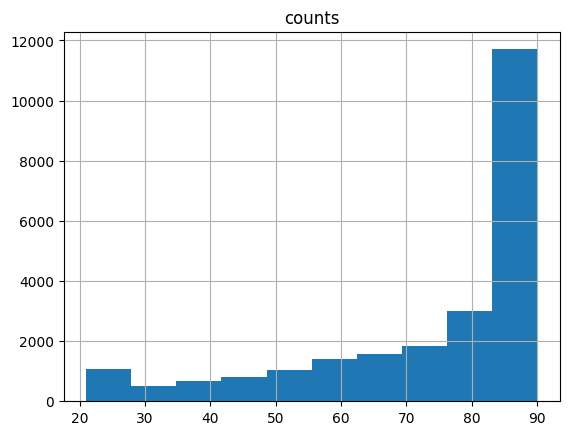

In [81]:
counts.hist()

In [87]:
counts[[]].to_csv("gene_names.csv")

In [88]:
pathlib

,counts,locus_group,symbol
HGNC:11858,86,protein-coding gene,TSPAN6
HGNC:17757,67,protein-coding gene,TNMD
HGNC:3005,90,protein-coding gene,DPM1
HGNC:19285,89,protein-coding gene,SCYL3
HGNC:25565,88,protein-coding gene,FIRRM
...,...,...,...
HGNC:56151,24,non-coding RNA,LINC03022
HGNC:49836,25,non-coding RNA,CASC21
HGNC:50610,22,non-coding RNA,LINC00976
HGNC:50496,31,non-coding RNA,DLEU1-AS1


In [82]:
counts = counts.merge(hgnc[["locus_group", "symbol"]], right_index=True, left_index=True)

array([[<Axes: title={'center': 'counts'}>]], dtype=object)

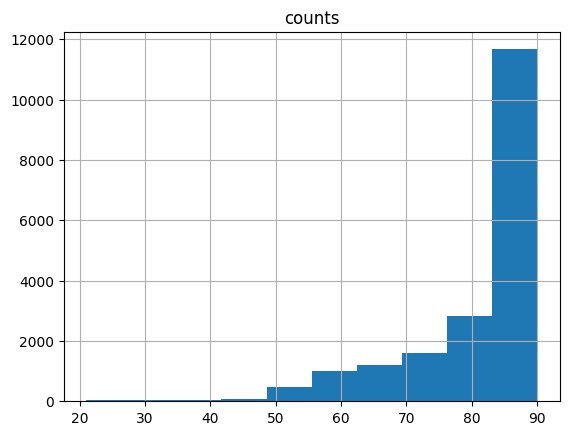

In [83]:
counts[counts["locus_group"] == "protein-coding gene"].hist()

In [76]:
genes_to_keep = counts[counts["counts"]>20].index

In [61]:
non_coding = counts[counts["locus_group"] != "protein-coding gene"]

In [65]:
non_coding.sort_values(["counts"], ascending=False).head(n=25)

,counts,locus_group,symbol
HGNC:28305,90,non-coding RNA,KRT10-AS1
HGNC:34425,90,non-coding RNA,ARIH2OS
HGNC:29667,90,pseudogene,C19orf48P
HGNC:4906,89,non-coding RNA,ANKRD13C-DT
HGNC:19078,89,non-coding RNA,SNHG32
HGNC:25561,88,pseudogene,FAM86C1P
HGNC:32670,88,pseudogene,TRIM16L
HGNC:44209,88,pseudogene,PPP5D1P
HGNC:26294,88,pseudogene,C22orf46P
HGNC:13605,88,pseudogene,FBXL9P


In [68]:
non_coding.loc[non_coding["symbol"].str.startswith("MT-")]
    

,counts,locus_group,symbol
HGNC:7490,12,non-coding RNA,MT-TL1
HGNC:7481,12,non-coding RNA,MT-TF
HGNC:7500,12,non-coding RNA,MT-TV
HGNC:7471,13,non-coding RNA,MT-RNR2
HGNC:7488,12,non-coding RNA,MT-TI
HGNC:7495,9,non-coding RNA,MT-TQ
HGNC:7492,12,non-coding RNA,MT-TM
HGNC:7501,10,non-coding RNA,MT-TW
HGNC:7475,8,non-coding RNA,MT-TA
HGNC:7493,6,non-coding RNA,MT-TN


In [77]:
for file in pathlib.Path("data").iterdir():
    adata = sc.read_h5ad(file)
    adata = adata[:, adata.var_names.isin(genes_to_keep)].copy()
    adata.write_h5ad(file)



HGNC:11858                      TSPAN6
HGNC:17757                        TNMD
HGNC:3005                         DPM1
HGNC:19285                       SCYL3
HGNC:25565                    C1orf112
                        ...           
HGNC:27599         LINC00908|LINC00683
HGNC:43460    MIR3670-2|hsa-mir-3670-2
HGNC:46264         RN7SL248P|RN7SL527P
HGNC:38967           MIR3690|MIR3690-1
HGNC:10228                RNU6-6P|U6-6
Name: symbol_author, Length: 33123, dtype: object